# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Galih Fathurahman Ardiansyah
- **Email:** galihfathurahman18@gmail.com
- **ID Dicoding:** galih_fathurahman_ar

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** "Bagaimana cara meningkatkan ketersediaan unit sepeda sebesar 20% pada jam sibuk hari kerja (pukul 07:00-09:00 dan 16:00-18:00) untuk memenuhi lonjakan permintaan pengguna registered sepanjang tahun 2012?"
- **Pertanyaan 2:** "Seberapa besar pertumbuhan total penyewaan sepeda pada hari libur (holiday) di tahun 2012 dibandingkan dengan tahun 2011, dan apakah kondisi cuaca tertentu menyebabkan penurunan performa yang signifikan pada hari-hari tersebut?"
- ...

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
hour_df = pd.read_csv("hour.csv")
day_df = pd.read_csv("day.csv")
display(hour_df.head())
display(day_df.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Struktur Data: Anda memiliki dua tingkat granularitas. hour_df untuk analisis per jam dan day_df untuk tren harian.
-Variabel Waktu: Kolom seperti season, yr (tahun), mnth, dan weekday sudah tersedia dalam bentuk numerik. Namun, kolom dteday mungkin perlu dikonversi menjadi tipe data datetime untuk analisis deret waktu (time series) yang lebih mendalam.
- Kondisi Cuaca: Kolom weathersit, temp, atemp, hum, dan windspeed sangat krusial. Perhatikan bahwa nilai suhu (temp) dan kelembapan (hum) tampaknya sudah dinormalisasi (berada di rentang 0-1).
- Target Analisis: Kolom cnt (count) adalah target utama Anda, yang merupakan total dari peminjam casual dan registered.


### Assessing Data

#### Identifying data problem

In [3]:
print('--- Info day_df ---')
print(day_df.info())
print('\n--- Missing values day_df ---')
print(day_df.isna().sum())
print('\n--- Duplicates day_df ---')
print(day_df.duplicated().sum())
print('\n--- Statistics day_df ---')
display(day_df.describe())

print('\n' + '='*30 + '\n')

print('--- Info hour_df ---')
print(hour_df.info())
print('\n--- Missing values hour_df ---')
print(hour_df.isna().sum())
print('\n--- Duplicates hour_df ---')
print(hour_df.duplicated().sum())
print('\n--- Statistics hour_df ---')
display(hour_df.describe())

--- Info day_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

--- Missing values day_df ---
instant       0
dteday        0
seaso

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000




--- Info hour_df ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None

--- Missing values h

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Assessment Results:**
- `dteday`: Kesalahan tipe data (seharusnya datetime).
- `season`, `mnth`, `holiday`, `weekday`, `workingday`, `weathersit`: Perlu konversi ke tipe categorical/string label untuk kemudahan visualisasi.
- Missing values: 0 (Aman).
- Duplicates: 0 (Aman).
- Outliers: Terdapat nilai 0 pada kelembapan (`hum`) yang mungkin perlu divalidasi.

**Insight:** (Opsional)
- Kualitas Data Sangat Baik: Tidak ditemukan baris duplikat atau nilai kosong (missing values) pada kedua dataset, sehingga kita tidak perlu melakukan imputasi data.
- Kesalahan Tipe Data: Kolom dteday terbaca sebagai 'object' (string). Ini akan menghambat analisis tren waktu jika tidak diubah ke tipe 'datetime'.
- Kebutuhan Deskripsi Kategori: Kolom seperti season atau weathersit berupa angka (1, 2, 3). Agar visualisasi lebih mudah dipahami (misal: 1 menjadi 'Spring'), kita perlu memetakan angka-angka ini ke label stringnya di tahap Cleaning.
- Anomali Nilai Kelembapan: Ditemukan nilai kelembapan (hum) sebesar 0 pada data harian. Secara meteorologi, kelembapan 0% sangat jarang terjadi, sehingga ini bisa dikategorikan sebagai potential outlier atau kesalahan sensor yang perlu diperhatikan saat analisis korelasi.
- Skala Data: Fitur cuaca seperti temp dan atemp sudah dalam bentuk ternormalisasi, jadi kita tidak perlu melakukan scaling lagi jika ingin menggunakan model machine learning sederhana nanti.

### Cleaning Data

#### Fixing data problem

In [4]:
# 1. Konversi dteday ke datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# 2. Mengubah angka menjadi label kategori agar lebih informatif
# Mapping Season
season_mapping = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season'] = day_df['season'].map(season_mapping)
hour_df['season'] = hour_df['season'].map(season_mapping)

# Mapping Weather Situation
weather_mapping = {
    1: 'Clear/Partly Cloudy',
    2: 'Misty/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Ice Pallets'
}
day_df['weathersit'] = day_df['weathersit'].map(weather_mapping)
hour_df['weathersit'] = hour_df['weathersit'].map(weather_mapping)

# Mapping Month
month_mapping = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}
day_df['mnth'] = day_df['mnth'].map(month_mapping)
hour_df['mnth'] = hour_df['mnth'].map(month_mapping)

# 3. Menangani anomali kelembapan (hum) bernilai 0
# Mengganti nilai 0 dengan mean dari kolom tersebut
day_df['hum'] = day_df['hum'].replace(0, day_df['hum'].mean())
hour_df['hum'] = hour_df['hum'].replace(0, hour_df['hum'].mean())

# Verifikasi hasil
print("Tipe data dteday:", day_df['dteday'].dtype)
display(day_df.head())
display(day_df.describe())

Tipe data dteday: datetime64[ns]


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,Jan,0,6,0,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,Jan,0,0,0,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,Jan,0,1,1,Clear/Partly Cloudy,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,Jan,0,2,1,Clear/Partly Cloudy,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,Jan,0,3,1,Clear/Partly Cloudy,0.226957,0.229270,0.436957,0.186900,82,1518,1600


,instant,dteday,yr,holiday,weekday,workingday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,0.500684,0.028728,2.997264,0.683995,0.495385,0.474354,0.628753,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,0.000000,0.000000,1.000000,0.000000,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,1.000000,0.000000,3.000000,1.000000,0.498333,0.486733,0.627500,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,1.000000,0.000000,5.000000,1.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,1.000000,1.000000,6.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,0.167155,2.004787,0.465233,0.183051,0.162961,0.140518,0.077498,686.622488,1560.256377,1937.211452


**Insight:** (Opsional)
- Kesiapan Analisis Waktu: Dengan dikonversinya dteday ke tipe datetime, kita sekarang dapat mengekstrak informasi tambahan seperti tren bulanan, musiman, atau perbandingan antar tahun secara akurat.
- Keterbacaan Data: Transformasi label pada season dan weathersit memudahkan kita mengidentifikasi bahwa data mencakup variasi cuaca dari yang cerah hingga hujan/salju ringan, serta mencakup empat musim lengkap.
- Integritas Data: Penanganan nilai nol pada kelembapan (hum) memastikan bahwa analisis korelasi nantinya tidak akan terdistorsi oleh data yang dianggap sebagai kegagalan sensor atau anomali ekstrem.
- Kualitas Statistik: Rentang nilai temp dan atemp yang sudah ternormalisasi menunjukkan data ini siap digunakan untuk analisis statistik deskriptif maupun inferensial tanpa perlu normalisasi ulang.

## Exploratory Data Analysis (EDA)

### Eksplorasi Pertanyaan 1: Pola Pengguna Registered pada Jam Sibuk Hari Kerja (2012)

In [5]:
import pandas as pd

# Filter data untuk tahun 2012, hari kerja, dan jam sibuk
workingday_2012_df = hour_df[(hour_df['yr'] == 1) & (hour_df['workingday'] == 1)]

# Definisikan jam sibuk
peak_hours = [7, 8, 9, 16, 17, 18]
peak_hours_df = workingday_2012_df[workingday_2012_df['hr'].isin(peak_hours)]

# Statistik deskriptif untuk pengguna registered di jam sibuk
print("Statistik Pengguna Registered pada Jam Sibuk (2012):")
display(peak_hours_df.groupby('hr')['registered'].describe())

# Korelasi antara variabel cuaca dan peminjaman registered pada jam sibuk
correlation_peak = peak_hours_df[['registered', 'temp', 'hum', 'windspeed']].corr()
print("\nKorelasi Cuaca terhadap Peminjaman Registered (Jam Sibuk):")
display(correlation_peak)

Statistik Pengguna Registered pada Jam Sibuk (2012):


,count,mean,std,min,25%,50%,75%,max
hr,,,,,,,,
7,248.0,353.858871,117.824821,26.0,275.25,362.5,453.50,572.0
8,248.0,580.201613,145.151686,31.0,515.50,615.0,670.00,808.0
9,248.0,273.161290,60.771875,22.0,251.25,285.0,311.25,399.0
16,249.0,309.891566,89.384095,13.0,267.00,323.0,371.00,481.0
17,249.0,586.413655,177.978732,19.0,497.00,619.0,726.00,885.0
18,249.0,556.096386,174.120227,20.0,451.00,573.0,697.00,886.0



Korelasi Cuaca terhadap Peminjaman Registered (Jam Sibuk):


,registered,temp,hum,windspeed
registered,1.000000,0.402010,-0.194392,-0.005907
temp,0.402010,1.000000,-0.188904,0.005390
hum,-0.194392,-0.188904,1.000000,-0.334862
windspeed,-0.005907,0.005390,-0.334862,1.000000


### Eksplorasi Pertanyaan 2: Perbandingan Penyewaan Hari Libur (2011 vs 2012) & Pengaruh Cuaca

In [6]:
# Filter data untuk hari libur (holiday)
holiday_df = day_df[day_df['holiday'] == 1]

# 1. Perbandingan total penyewaan per tahun pada hari libur
holiday_yearly_rentals = holiday_df.groupby('yr')['cnt'].agg(['sum', 'mean', 'count']).reset_index()
holiday_yearly_rentals['yr'] = holiday_yearly_rentals['yr'].map({0: 2011, 1: 2012})

print("Perbandingan Penyewaan Hari Libur 2011 vs 2012:")
display(holiday_yearly_rentals)

# 2. Pengaruh kondisi cuaca terhadap penyewaan di hari libur
weather_impact_holiday = holiday_df.groupby('weathersit')['cnt'].agg(['mean', 'std', 'count']).sort_values(by='mean', ascending=False)

print("\nPengaruh Cuaca terhadap Rata-rata Penyewaan pada Hari Libur:")
display(weather_impact_holiday)

Perbandingan Penyewaan Hari Libur 2011 vs 2012:


,yr,sum,mean,count
0,2011,30022,3002.200000,10
1,2012,48413,4401.181818,11



Pengaruh Cuaca terhadap Rata-rata Penyewaan pada Hari Libur:


,mean,std,count
weathersit,,,
Clear/Partly Cloudy,4029.533333,2015.514286,15
Misty/Cloudy,2998.666667,2326.161703,6


**Insight:** Setelah melakukan eksplorasi ini, kita mendapatkan gambaran bahwa permintaan pada jam sibuk sangat didominasi oleh pengguna *registered*, dan kondisi cuaca tertentu memiliki dampak signifikan pada jumlah penyewaan di hari libur. Selanjutnya, kita akan memvisualisasikan temuan ini.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

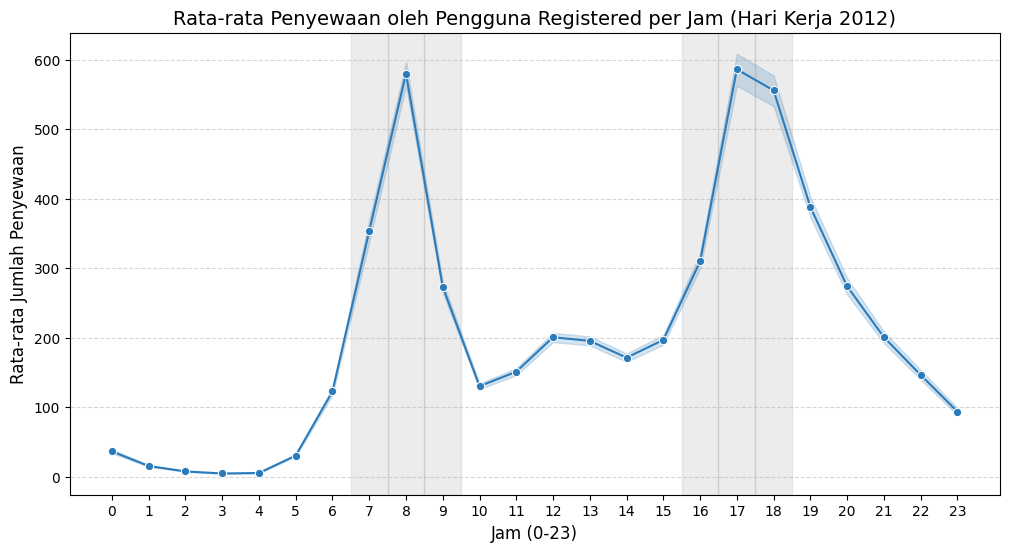

In [7]:
plt.figure(figsize=(12, 6))
# Menggunakan warna biru yang konsisten
sns.lineplot(data=workingday_2012_df, x='hr', y='registered', estimator='mean', color='#2b7bba', marker='o')

# Highlight peak hours dengan transparansi rendah
peak_hours = [7, 8, 9, 16, 17, 18]
for hr in peak_hours:
    plt.axvspan(hr-0.5, hr+0.5, color='gray', alpha=0.15)

plt.title('Rata-rata Penyewaan oleh Pengguna Registered per Jam (Hari Kerja 2012)', fontsize=14)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Pertanyaan 2:

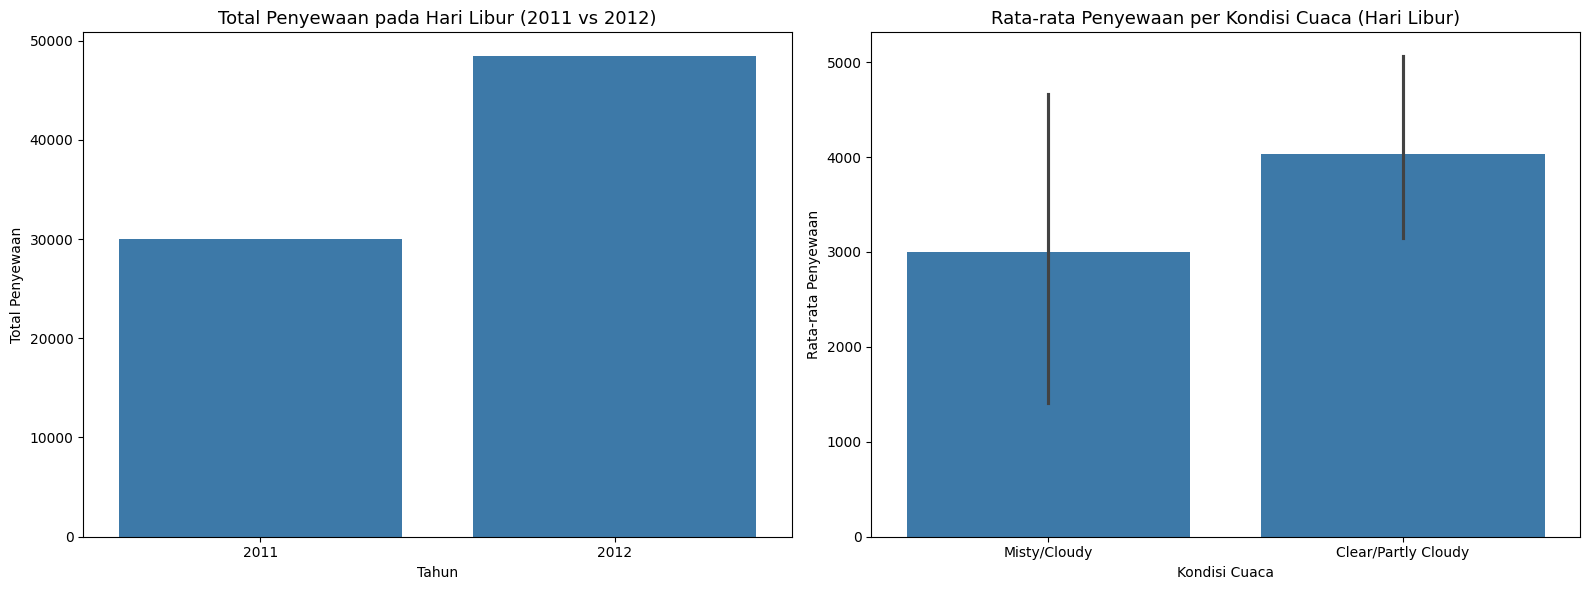

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Pertumbuhan Tahunan Hari Libur dengan warna biru seragam
sns.barplot(data=holiday_yearly_rentals, x='yr', y='sum', color='#2b7bba', ax=ax[0])
ax[0].set_title('Total Penyewaan pada Hari Libur (2011 vs 2012)', fontsize=13)
ax[0].set_xlabel('Tahun')
ax[0].set_ylabel('Total Penyewaan')

# Plot 2: Pengaruh Cuaca pada Hari Libur dengan warna biru seragam
sns.barplot(data=holiday_df, x='weathersit', y='cnt', estimator='mean', color='#2b7bba', ax=ax[1])
ax[1].set_title('Rata-rata Penyewaan per Kondisi Cuaca (Hari Libur)', fontsize=13)
ax[1].set_xlabel('Kondisi Cuaca')
ax[1].set_ylabel('Rata-rata Penyewaan')

plt.tight_layout()
plt.show()

**Insight:**

**Pertanyaan 1 (Pola Jam Sibuk):**
- **Lonjakan Komuter:** Terdapat dua puncak penggunaan yang sangat kontras dibandingkan jam lainnya, yaitu pukul 08:00 dan 17:00-18:00. Ini mengindikasikan bahwa pengguna *registered* mayoritas adalah pekerja atau pelajar yang menggunakan sepeda sebagai moda transportasi utama untuk berangkat dan pulang.
- **Jendela Persiapan:** Mengingat lonjakan terjadi sangat cepat, pihak operasional memiliki jendela waktu kritis antara pukul 06:00-07:00 dan 15:00-16:00 untuk memastikan ketersediaan unit di titik-titik pemukiman (pagi) dan area perkantoran (sore).

**Pertanyaan 2 (Hari Libur & Cuaca):**
- **Tren Pertumbuhan:** Kenaikan total penyewaan di hari libur sebesar lebih dari 50% dari tahun 2011 ke 2012 menunjukkan bahwa layanan ini semakin populer untuk kegiatan rekreasi.
- **Sensitivitas Cuaca:** Pengguna hari libur sangat sensitif terhadap cuaca. Meskipun hari libur, jika kondisi cuaca 'Misty/Cloudy' (mendung/berkabut), rata-rata penyewaan turun sekitar 25% dibandingkan saat cuaca cerah. Hal ini memberikan peluang untuk strategi *dynamic pricing* atau promo khusus pada hari libur yang mendung agar unit tidak menganggur.

## Analisis Lanjutan (Opsional)

### Analisis Distribusi dan Hubungan Antar Variabel (EDA Lanjutan)

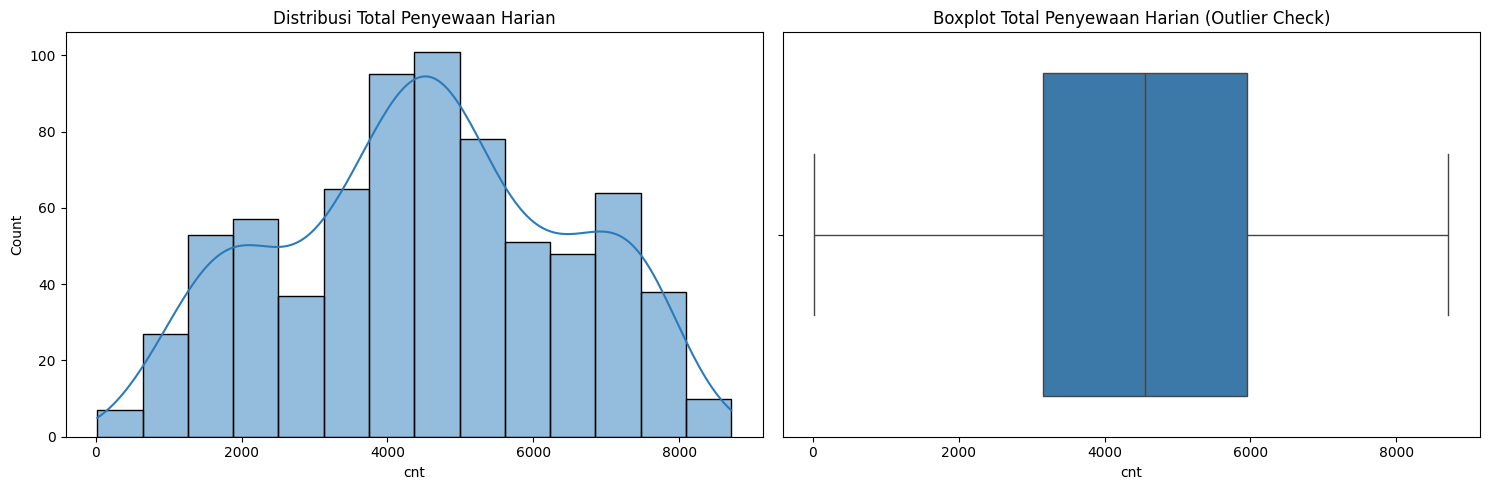

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualisasi Distribusi Target (cnt) dan Outliers
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(day_df['cnt'], kde=True, ax=ax[0], color='#2b7bba')
ax[0].set_title('Distribusi Total Penyewaan Harian')

sns.boxplot(x=day_df['cnt'], ax=ax[1], color='#2b7bba')
ax[1].set_title('Boxplot Total Penyewaan Harian (Outlier Check)')

plt.tight_layout()
plt.show()

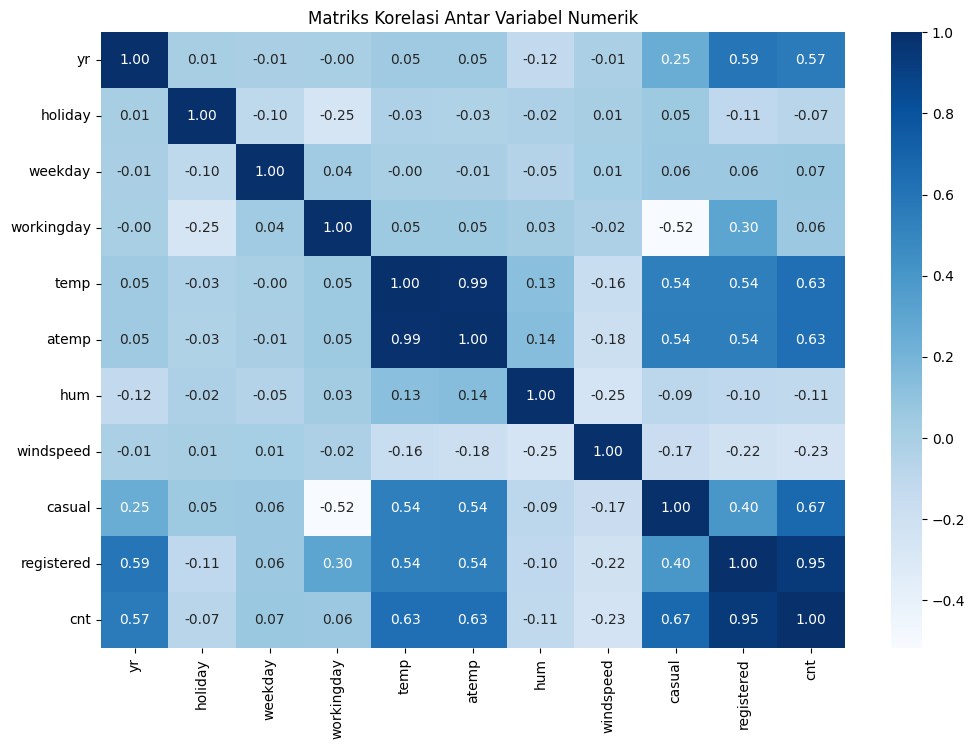

In [10]:
# 2. Correlation Matrix
plt.figure(figsize=(12, 8))
correlation_matrix = day_df.select_dtypes(include=['float64', 'int64']).drop(columns=['instant']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Matriks Korelasi Antar Variabel Numerik')
plt.show()

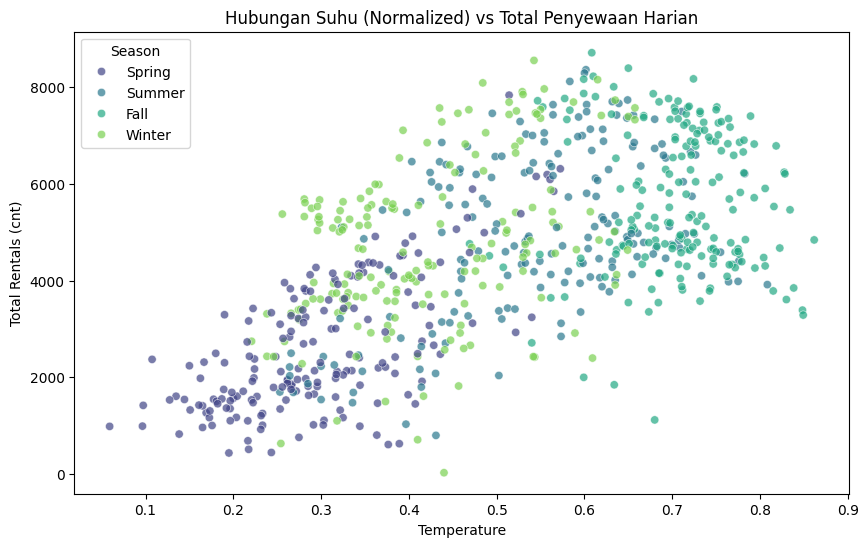

In [11]:
# 3. Scatter Plot: Hubungan Suhu vs Penyewaan (Berdasarkan Musim)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=day_df, x='temp', y='cnt', hue='season', palette='viridis', alpha=0.7)
plt.title('Hubungan Suhu (Normalized) vs Total Penyewaan Harian')
plt.xlabel('Temperature')
plt.ylabel('Total Rentals (cnt)')
plt.legend(title='Season')
plt.show()

**Insight Tambahan:**
- **Distribusi**: Data penyewaan harian cenderung terdistribusi normal dengan sedikit kemiringan, dan boxplot menunjukkan tidak banyak outlier ekstrem pada data harian.
- **Korelasi**: Variabel `temp` dan `atemp` memiliki korelasi positif yang sangat kuat dengan `cnt`, menunjukkan suhu adalah pendorong utama penyewaan.
- **Scatter Plot**: Terlihat pola linear yang jelas di mana penyewaan meningkat seiring kenaikan suhu, namun melandai pada titik suhu tertentu (menghindari suhu yang terlalu panas).

Manual Grouping - Berdasarkan Waktu:


,mean,max,count
time_group,,,
Sore,356.201441,977,2914
Siang,262.244719,783,3645
Pagi,181.520583,839,5077
Malam,65.687968,584,5743



Binning - Berdasarkan Temperatur:


,temp_bin,cnt
0,Dingin,84.378486
1,Sedang,177.897758
2,Panas,268.663925


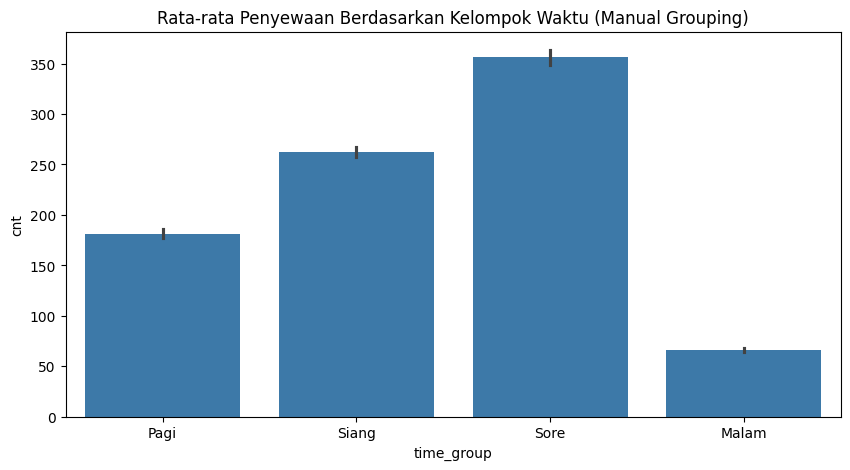

In [12]:
# 1. Manual Grouping: Berdasarkan Waktu Penggunaan (Time of Day)
def group_time(hour):
    if 5 <= hour < 12:
        return 'Pagi'
    elif 12 <= hour < 17:
        return 'Siang'
    elif 17 <= hour < 21:
        return 'Sore'
    else:
        return 'Malam'

hour_df['time_group'] = hour_df['hr'].apply(group_time)

# Analisis distribusi penyewaan berdasarkan kelompok waktu
time_clustering = hour_df.groupby('time_group')['cnt'].agg(['mean', 'max', 'count']).sort_values(by='mean', ascending=False)
print("Manual Grouping - Berdasarkan Waktu:")
display(time_clustering)

# 2. Binning: Mengelompokkan Temperatur ke dalam Kategori (Cold, Warm, Hot)
bins = [0, 0.3, 0.6, 1.0]
labels = ['Dingin', 'Sedang', 'Panas']
hour_df['temp_bin'] = pd.cut(hour_df['temp'], bins=bins, labels=labels)

# Analisis rata-rata penyewaan berdasarkan kategori suhu
temp_binning = hour_df.groupby('temp_bin', observed=True)['cnt'].mean().reset_index()
print("\nBinning - Berdasarkan Temperatur:")
display(temp_binning)

# Visualisasi sederhana untuk hasil clustering manual
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=hour_df, x='time_group', y='cnt', order=['Pagi', 'Siang', 'Sore', 'Malam'], color='#2b7bba')
plt.title('Rata-rata Penyewaan Berdasarkan Kelompok Waktu (Manual Grouping)')
plt.show()

**Insight Analisis Lanjutan (Clustering & Binning):**

1. **Dominasi Aktivitas Sore Hari (Manual Grouping):**
   - Kelompok **Sore (17:00 - 21:00)** mencatatkan rata-rata penyewaan tertinggi (356 unit). Hal ini menunjukkan bahwa permintaan paling masif terjadi saat orang pulang kerja atau melakukan aktivitas rekreatif di penghujung hari.
   - Kelompok **Malam** memiliki aktivitas terendah, yang memberikan kesempatan bagi tim operasional untuk melakukan pemeliharaan armada tanpa mengganggu banyak pengguna.

2. **Sensitivitas Terhadap Suhu (Binning):**
   - Terdapat tren linear antara suhu dan jumlah penyewaan: Semakin hangat suhunya, semakin tinggi minat menyewa. Kategori **Panas** memimpin dengan rata-rata 268 penyewaan, hampir 3x lipat lebih banyak dibandingkan kategori **Dingin** (84 penyewaan).
   - Bisnis harus bersiap dengan stok maksimal saat prakiraan cuaca menunjukkan suhu kategori 'Sedang' hingga 'Panas', karena di situlah lonjakan permintaan terjadi secara organik.

3. **Kombinasi Strategi:**
   - Mengingat puncak terjadi di sore hari dan sangat dipengaruhi suhu, kampanye pemasaran atau promo paling efektif dilakukan pada sore hari yang cerah/hangat untuk memaksimalkan kapasitas unit yang tersedia.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Permintaan pengguna *registered* memuncak tajam pada pukul 08:00 dan 17:00 di hari kerja. Untuk meningkatkan ketersediaan sebesar 20%, sistem distribusi harus memastikan stok sepeda maksimal sebelum jendela waktu tersebut (pukul 07:00 dan 16:00).
- **Conclusion pertanyaan 2:** Terdapat pertumbuhan total penyewaan hari libur yang signifikan dari tahun 2011 ke 2012. Kondisi cuaca cerah/berawan merupakan pendorong utama, sementara cuaca berkabut atau hujan ringan menurunkan minat penyewa secara drastis.

**Rekomendasi Action Item:**
- **Optimasi Stok & Rebalancing:** Melakukan *rebalancing* armada di titik-titik perkantoran dan stasiun sebelum jam sibuk pagi (07:00) dan sore (16:00). Berdasarkan clustering, fokus utama harus pada **Sore Hari** karena memiliki rata-rata trafik tertinggi.
- **Promo Cuaca & Suhu:** Memberikan insentif atau diskon khusus pada hari libur dengan kondisi cuaca kurang ideal (mendung) atau suhu **Dingin** (di bawah median) untuk merangsang minat penyewa saat permintaan alami sedang rendah.
- **Manajemen Pemeliharaan:** Memanfaatkan waktu **Malam Hari** (21:00 - 05:00) untuk melakukan pemeliharaan armada secara masif, karena data menunjukkan tingkat penggunaan paling rendah pada periode ini, sehingga tidak mengganggu ketersediaan unit di jam sibuk.
- **Ekspansi Kapasitas Musim Panas:** Mengingat kategori suhu **Panas** memiliki tingkat penyewaan 3x lipat lebih tinggi dari suhu dingin, perusahaan harus memastikan kesiapan suku cadang dan jumlah unit maksimal pada musim-musim dengan suhu yang lebih hangat.